# Setup and Dependencies

In [1]:


import os, glob, shutil, random, zipfile, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import cv2
import shap

from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              roc_auc_score, confusion_matrix, classification_report)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

Device: cuda


# Data Loading

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ZIP_PATH = '/content/drive/MyDrive/data.zip'
extract_dir = '/content/data'

if os.path.isfile(DRIVE_ZIP_PATH):
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zf:
        zf.extractall(extract_dir)
    print("Extracted to:", extract_dir)
else:
    print(f"Couldn't find {DRIVE_ZIP_PATH}")

Mounted at /content/drive
Extracted to: /content/data


In [3]:
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

CLASS_ALIASES = {
    'glioma': 'glioma', 'glioma_tumor': 'glioma',
    'meningioma': 'meningioma', 'meningioma_tumor': 'meningioma',
    'notumor': 'notumor', 'no_tumor': 'notumor', 'no tumor': 'notumor',
    'pituitary': 'pituitary', 'pituitary_tumor': 'pituitary',
}

DATA_ROOT = '/content/data'

def find_class_dirs(root):
    matches = []
    for dirpath, dirnames, _ in os.walk(root):
        base = os.path.basename(dirpath).strip().lower().replace('-', '_')
        if base in CLASS_ALIASES:
            matches.append((dirpath, CLASS_ALIASES[base]))
    return matches

def collect_image_paths(root):
    records = []
    for cls_path, cls in find_class_dirs(root):
        for fname in os.listdir(cls_path):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                records.append({'filepath': os.path.join(cls_path, fname), 'label': cls})
    return pd.DataFrame(records, columns=['filepath', 'label'])

df = collect_image_paths(DATA_ROOT)
if len(df) > 0:
    print(df['label'].value_counts())
    print("Total images:", len(df))

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED)
print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

label
notumor       1800
meningioma    1800
glioma        1800
pituitary     1800
Name: count, dtype: int64
Total images: 7200
Train: 5040 Val: 1080 Test: 1080


# CLAHE Preprocessing

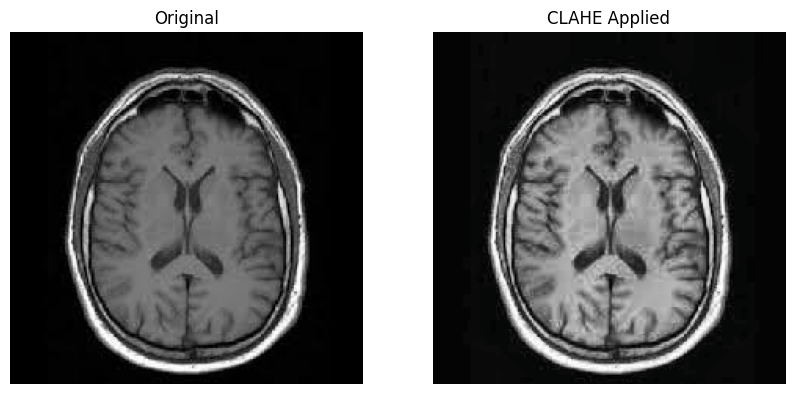

In [4]:
class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        # img is expected to be a PIL Image or numpy array
        img_np = np.array(img)
        if len(img_np.shape) == 3 and img_np.shape[2] == 3:
            # Convert to LAB color space
            lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(lab)

            # Apply CLAHE to L-channel
            cl = self.clahe.apply(l)

            # Merge and convert back to RGB
            limg = cv2.merge((cl, a, b))
            img_clahe = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
            return Image.fromarray(img_clahe)
        else:
            # Grayscale image
            cl = self.clahe.apply(img_np)
            return Image.fromarray(cl)

# Visualization
sample_path = train_df.iloc[0]['filepath']
orig_img = Image.open(sample_path).convert('RGB')
clahe_transform = CLAHETransform()
clahe_img = clahe_transform(orig_img)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(orig_img); axs[0].set_title('Original'); axs[0].axis('off')
axs[1].imshow(clahe_img); axs[1].set_title('CLAHE Applied'); axs[1].axis('off')
plt.show()

In [5]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class BrainTumorDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['filepath']).convert('RGB')
        label = CLASS_TO_IDX[row['label']]
        if self.transform:
            img = self.transform(img)
        return img, label

BATCH_SIZE = 32
train_ds = BrainTumorDataset(train_df, train_transform)
val_ds   = BrainTumorDataset(val_df, eval_transform)
test_ds  = BrainTumorDataset(test_df, eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, persistent_workers=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Train new PDSCNN

In [6]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, stride=1):
        super().__init__()
        padding = kernel_size // 2
        self.depthwise = nn.Conv2d(in_ch, in_ch, kernel_size, stride=stride,
                                    padding=padding, groups=in_ch, bias=False)
        self.pointwise = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        return self.relu(x)

class ParallelDSBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        branch_ch = out_ch // 2
        self.branch_a = DepthwiseSeparableConv(in_ch, branch_ch, kernel_size=3, stride=stride)
        self.branch_b = DepthwiseSeparableConv(in_ch, branch_ch, kernel_size=5, stride=stride)
        self.fuse = nn.Sequential(
            nn.Conv2d(branch_ch * 2, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        a = self.branch_a(x)
        b = self.branch_b(x)
        x = torch.cat([a, b], dim=1)
        return self.fuse(x)

class PDSCNN(nn.Module):
    def __init__(self, num_classes=4, in_ch=3, widths=(32, 64, 128, 256, 512)):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_ch, widths[0], 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(widths[0]),
            nn.ReLU(inplace=True),
        )
        stages = []
        in_c = widths[0]
        for w in widths[1:]:
            stages.append(ParallelDSBlock(in_c, w, stride=2))
            in_c = w
        self.stages = nn.Sequential(*stages)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.feature_dim = widths[-1]
        self.classifier = nn.Linear(self.feature_dim, num_classes)

    def forward_features(self, x):
        x = self.stem(x)
        x = self.stages(x)
        return self.gap(x).flatten(1)

    def forward(self, x):
        feat = self.forward_features(x)
        return self.classifier(feat), feat

pdscnn = PDSCNN(num_classes=len(CLASS_NAMES)).to(device)

In [7]:
def train_pdscnn(model, train_loader, val_loader, epochs=25, lr=1e-3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for imgs, labels in tqdm(train_loader, desc=f"PDSCNN Epoch {epoch+1}/{epochs}"):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits, _ = model(imgs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)

        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                logits, _ = model(imgs)
                val_loss += criterion(logits, labels).item() * imgs.size(0)
                correct += (logits.argmax(1) == labels).sum().item()

        val_acc = correct / len(val_loader.dataset)
        scheduler.step()
        print(f"Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'pdscnn_clahe_best.pth')

train_pdscnn(pdscnn, train_loader, val_loader, epochs=20)
pdscnn.load_state_dict(torch.load('pdscnn_clahe_best.pth'))

PDSCNN Epoch 1/20:   0%|          | 0/158 [00:00<?, ?it/s]

Val Acc: 0.7870


PDSCNN Epoch 2/20:   0%|          | 0/158 [00:00<?, ?it/s]

Val Acc: 0.6667


PDSCNN Epoch 3/20:   0%|          | 0/158 [00:00<?, ?it/s]

...

PDSCNN Epoch 19/20:   0%|          | 0/158 [00:00<?, ?it/s]

Val Acc: 0.9620


PDSCNN Epoch 20/20:   0%|          | 0/158 [00:00<?, ?it/s]

Val Acc: 0.9639


<All keys matched successfully>

# Fine-tune Pretrained ViT

In [8]:
from transformers import ViTForImageClassification

VIT_CKPT = "google/vit-base-patch16-224-in21k"
vit_model = ViTForImageClassification.from_pretrained(
    VIT_CKPT,
    num_labels=len(CLASS_NAMES),
    ignore_mismatched_sizes=True
).to(device)

# Freeze all except the last transformer layer and classifier
for name, param in vit_model.named_parameters():
    if 'vit.encoder.layer.11' in name or 'vit.layernorm' in name or 'classifier' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

print(f"ViT Trainable params: {sum(p.numel() for p in vit_model.parameters() if p.requires_grad):,}")

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/6 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.output.dense.bias                | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.weight           | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.weight              | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.weight        | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.weight | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.weight | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.weight    | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.bias             | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.bias   | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.bias   | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.wei

ViT Trainable params: 4,612


In [9]:
def train_vit(model, train_loader, val_loader, epochs=5, lr=2e-5):
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        for imgs, labels in tqdm(train_loader, desc=f"ViT Epoch {epoch+1}/{epochs}"):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(pixel_values=imgs, labels=labels)
            outputs.loss.backward()
            optimizer.step()

        model.eval()
        correct = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(pixel_values=imgs)
                correct += (outputs.logits.argmax(1) == labels).sum().item()

        val_acc = correct / len(val_loader.dataset)
        print(f"ViT Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'vit_finetuned_best.pth')

train_vit(vit_model, train_loader, val_loader, epochs=5)
vit_model.load_state_dict(torch.load('vit_finetuned_best.pth'))

ViT Epoch 1/5:   0%|          | 0/158 [00:00<?, ?it/s]

ViT Val Acc: 0.2880


ViT Epoch 2/5:   0%|          | 0/158 [00:00<?, ?it/s]

ViT Val Acc: 0.4509


ViT Epoch 3/5:   0%|          | 0/158 [00:00<?, ?it/s]

...

ViT Epoch 4/5:   0%|          | 0/158 [00:00<?, ?it/s]

ViT Val Acc: 0.4685


ViT Epoch 5/5:   0%|          | 0/158 [00:00<?, ?it/s]

ViT Val Acc: 0.4778


<All keys matched successfully>

# Feature Fusion and RRELM Classifier

In [10]:
def get_finetuned_vit_features(model, pixel_values):
    with torch.no_grad():
        outputs = model.vit(pixel_values=pixel_values)
        return outputs.last_hidden_state[:, 0, :]  # CLS token

def extract_fused_features(loader, pdscnn_model, vit_model, desc="extract"):
    pdscnn_model.eval()
    vit_model.eval()
    all_feats, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=desc):
            imgs = imgs.to(device)
            _, pdscnn_feat = pdscnn_model(imgs)
            vit_feat = get_finetuned_vit_features(vit_model, imgs)
            fused = torch.cat([vit_feat, pdscnn_feat], dim=1)
            all_feats.append(fused.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_feats), np.concatenate(all_labels)

train_ds_eval = BrainTumorDataset(train_df, eval_transform)
train_loader_eval = DataLoader(train_ds_eval, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

X_train, y_train = extract_fused_features(train_loader_eval, pdscnn, vit_model, "train features")
X_val, y_val     = extract_fused_features(val_loader, pdscnn, vit_model, "val features")
X_test, y_test   = extract_fused_features(test_loader, pdscnn, vit_model, "test features")

train features:   0%|          | 0/158 [00:00<?, ?it/s]

val features:   0%|          | 0/34 [00:00<?, ?it/s]

test features:   0%|          | 0/34 [00:00<?, ?it/s]

In [11]:
class RRELM:
    def __init__(self, n_hidden=512, C=1.0, activation='sigmoid', random_state=42):
        self.n_hidden = n_hidden
        self.C = C
        self.activation = activation
        self.rng = np.random.RandomState(random_state)

    def _activate(self, H):
        return 1.0 / (1.0 + np.exp(-H))

    def fit(self, X, y_onehot):
        self.W = self.rng.uniform(-1, 1, size=(X.shape[1], self.n_hidden))
        self.b = self.rng.uniform(-1, 1, size=(self.n_hidden,))
        H = self._activate(X @ self.W + self.b)
        n = H.shape[0]
        if n >= self.n_hidden:
            I = np.eye(self.n_hidden)
            self.beta = np.linalg.solve(H.T @ H + I / self.C, H.T @ y_onehot)
        else:
            I = np.eye(n)
            self.beta = H.T @ np.linalg.solve(H @ H.T + I / self.C, y_onehot)
        return self

    def predict_proba(self, X):
        H = self._activate(X @ self.W + self.b)
        return H @ self.beta

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
X_val_s = scaler.transform(X_val)

X_cv = np.concatenate([X_train_s, X_val_s])
y_cv = np.concatenate([y_train, y_val])

def to_onehot(y, n_classes):
    oh = np.zeros((len(y), n_classes))
    oh[np.arange(len(y)), y] = 1
    return oh

final_rrelm = RRELM(n_hidden=1024, C=10.0, activation='sigmoid', random_state=SEED)
final_rrelm.fit(X_cv, to_onehot(y_cv, 4))

test_preds = final_rrelm.predict(X_test_s)
print(f"Test Accuracy:  {accuracy_score(y_test, test_preds):.4f}")
print(classification_report(y_test, test_preds, target_names=CLASS_NAMES))

Test Accuracy:  0.9574
              precision    recall  f1-score   support

      glioma       0.98      0.91      0.94       270
  meningioma       0.92      0.96      0.94       270
     notumor       0.96      0.97      0.97       270
   pituitary       0.98      0.99      0.99       270

    accuracy                           0.96      1080
   macro avg       0.96      0.96      0.96      1080
weighted avg       0.96      0.96      0.96      1080



# Explainability: GradCAM and SHAP

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.7-py3-none-any.whl size=53345 sha256=0a435cbf9b851ac55e9ad0593e6927cbaef5ea918a09139e20bd69e72d4f536c
  Stored in directory: /root/.cache/pip/wheels/91/36/f0/c2367865493d51b13369769181beca14603d17d6539a5922e3
Successfully built grad-cam


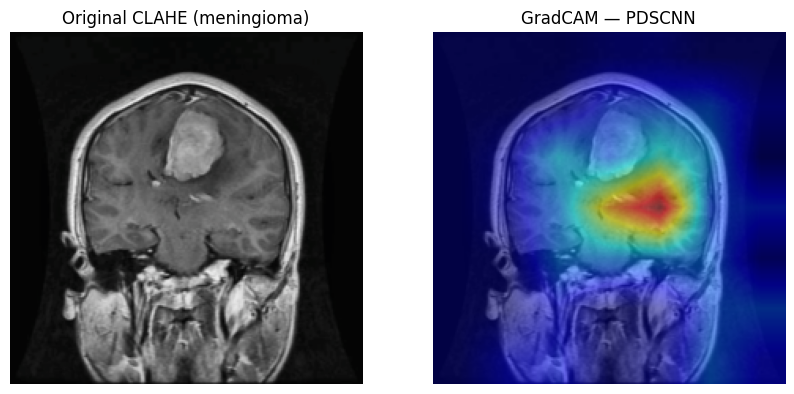

In [14]:
!pip install grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

class PDSCNNLogitsOnly(nn.Module):
    def __init__(self, base):
        super().__init__()
        self.base = base
    def forward(self, x):
        logits, _ = self.base(x)
        return logits

pdscnn_wrapped = PDSCNNLogitsOnly(pdscnn).to(device)
target_layers = [pdscnn.stages[-1].fuse[0]]
cam = GradCAM(model=pdscnn_wrapped, target_layers=target_layers)

def denormalize(img_tensor):
    img = img_tensor.clone().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img, 0, 1)

sample_img, sample_label = test_ds[0]
input_tensor = sample_img.unsqueeze(0).to(device)

grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]
rgb_img = denormalize(sample_img)
cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(rgb_img); axs[0].set_title(f"Original CLAHE ({CLASS_NAMES[sample_label]})"); axs[0].axis('off')
axs[1].imshow(cam_image); axs[1].set_title("GradCAM — PDSCNN"); axs[1].axis('off')
plt.show()

Raw SHAP shape: (1, 3, 224, 224, 1)
After removing output dimension: (1, 3, 224, 224)
Final SHAP shape: (1, 224, 224, 3)
Image shape: (1, 224, 224, 3)
Explained class index: tensor([[1]], device='cuda:0')


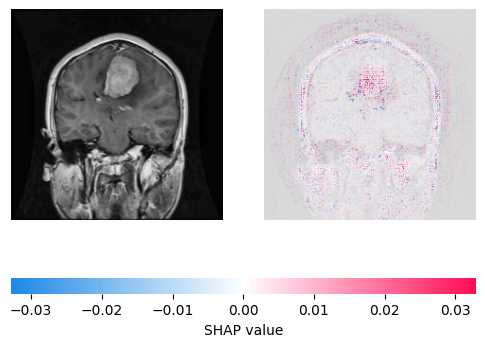

In [17]:
# ==========================================
# SHAP Visualization on PDSCNN
# ==========================================

# Use training images as background
background = torch.stack(
    [train_ds[i][0] for i in range(10)]
).to(device)

# Create GradientExplainer
e = shap.GradientExplainer(
    pdscnn_wrapped,
    background
)

# Calculate SHAP values
shap_values, indexes = e.shap_values(
    input_tensor,
    ranked_outputs=1
)

# ------------------------------------------
# Convert SHAP output to NumPy
# ------------------------------------------

if isinstance(shap_values, list):
    shap_numpy = np.asarray(shap_values[0])
else:
    shap_numpy = np.asarray(shap_values)

print("Raw SHAP shape:", shap_numpy.shape)

# New SHAP versions can return:
# (N, C, H, W, outputs)
# Remove the output dimension
if shap_numpy.ndim == 5:
    shap_numpy = np.squeeze(shap_numpy, axis=-1)

print("After removing output dimension:", shap_numpy.shape)

# ------------------------------------------
# Convert SHAP from NCHW -> NHWC if needed
# ------------------------------------------

if shap_numpy.ndim == 4:

    # If shape is (N, C, H, W)
    if shap_numpy.shape[1] in [1, 3]:
        shap_numpy = np.transpose(
            shap_numpy,
            (0, 2, 3, 1)
        )

    # Otherwise assume already (N, H, W, C)

elif shap_numpy.ndim == 3:

    # Add batch dimension
    shap_numpy = np.expand_dims(
        shap_numpy,
        axis=0
    )

else:
    raise ValueError(
        f"Unexpected SHAP shape: {shap_numpy.shape}"
    )

# ------------------------------------------
# Prepare original image
# ------------------------------------------

test_numpy = input_tensor.detach().cpu().numpy()

# NCHW -> NHWC
test_numpy = np.transpose(
    test_numpy,
    (0, 2, 3, 1)
)

# Denormalize
test_numpy = (
    test_numpy * np.array(IMAGENET_STD)
    + np.array(IMAGENET_MEAN)
)

test_numpy = np.clip(
    test_numpy,
    0,
    1
)

print("Final SHAP shape:", shap_numpy.shape)
print("Image shape:", test_numpy.shape)
print("Explained class index:", indexes)

# ------------------------------------------
# SHAP visualization
# ------------------------------------------

shap.image_plot(
    [shap_numpy],
    test_numpy,
    width=15
)